In [1]:
import h5py
import numpy as np
from pathlib import Path

src_path = 'data/grid_results/Photochem_1D_updatop_paramext_reducedrad_full_try3.h5'
dst_path = 'data/grid_results/Photochem_1D_lowmetal_restart.h5'

METAL_CUTOFF = 2.375  # keep metallicities <= this value
METAL_AXIS   = 1      # metallicity is axis 1 in all result arrays
N_PARAMS     = 6      # columns in the flat inputs array

In [2]:
# Inspect source h5 and store key variables for later cells
with h5py.File(src_path, 'r') as f:
    inputs_flat   = f['inputs'][:]       # shape (N_total, 6)
    completed_flat = f['completed'][:]   # shape (N_total,)
    result_keys    = list(f['results'].keys())
    result_shapes  = {k: f['results'][k].shape for k in result_keys}

print(f"inputs shape   : {inputs_flat.shape}")
print(f"completed shape: {completed_flat.shape}  ({completed_flat.sum()} done)")
print(f"\nresult datasets ({len(result_keys)}):")
for k, s in sorted(result_shapes.items()):
    print(f"  {k}: {s}")

inputs shape   : (11880, 6)
completed shape: (11880,)  (11880 done)

result datasets (180):
  1CH2_sol: (1, 9, 8, 11, 5, 3, 100)
  1CH2_soleq: (1, 9, 8, 11, 5, 3, 100)
  C2H2OH_sol: (1, 9, 8, 11, 5, 3, 100)
  C2H2OH_soleq: (1, 9, 8, 11, 5, 3, 100)
  C2H2_sol: (1, 9, 8, 11, 5, 3, 100)
  C2H2_soleq: (1, 9, 8, 11, 5, 3, 100)
  C2H2aer_sol: (1, 9, 8, 11, 5, 3, 100)
  C2H2aer_soleq: (1, 9, 8, 11, 5, 3, 100)
  C2H3OH_sol: (1, 9, 8, 11, 5, 3, 100)
  C2H3OH_soleq: (1, 9, 8, 11, 5, 3, 100)
  C2H3_sol: (1, 9, 8, 11, 5, 3, 100)
  C2H3_soleq: (1, 9, 8, 11, 5, 3, 100)
  C2H4OH_sol: (1, 9, 8, 11, 5, 3, 100)
  C2H4OH_soleq: (1, 9, 8, 11, 5, 3, 100)
  C2H4_sol: (1, 9, 8, 11, 5, 3, 100)
  C2H4_soleq: (1, 9, 8, 11, 5, 3, 100)
  C2H4aer_sol: (1, 9, 8, 11, 5, 3, 100)
  C2H4aer_soleq: (1, 9, 8, 11, 5, 3, 100)
  C2H5_sol: (1, 9, 8, 11, 5, 3, 100)
  C2H5_soleq: (1, 9, 8, 11, 5, 3, 100)
  C2H6_sol: (1, 9, 8, 11, 5, 3, 100)
  C2H6_soleq: (1, 9, 8, 11, 5, 3, 100)
  C2H6aer_sol: (1, 9, 8, 11, 5, 3, 100)
  C2H6ae

In [3]:
# Infer grid shape from any result array (shape = grid_shape + (n_layers,))
sample_shape = next(iter(result_shapes.values()))
grid_shape   = sample_shape[:-1]   # drop trailing layers dimension
print(f"Grid shape (n_rad, n_metal, n_tint, n_semi, n_ctoO, n_Kzz): {grid_shape}")
assert np.prod(grid_shape) == inputs_flat.shape[0], \
    f"Mismatch: prod(grid_shape)={np.prod(grid_shape)} != inputs rows={inputs_flat.shape[0]}"

# Reshape inputs to n-d so we can slice axis 1
inputs_nd  = inputs_flat.reshape(grid_shape + (N_PARAMS,))

# Metallicity values live in column 1; recover them along axis 1
metal_vals = inputs_nd[0, :, 0, 0, 0, 0, 1]   # shape (n_metal,)
metal_keep = np.where(metal_vals <= METAL_CUTOFF)[0]

new_grid_shape = grid_shape[:METAL_AXIS] + (len(metal_keep),) + grid_shape[METAL_AXIS+1:]

print(f"\nMetallicity values in source : {metal_vals}")
print(f"Keeping indices              : {metal_keep}")
print(f"Keeping metallicity values   : {metal_vals[metal_keep]}")
print(f"\nOld grid shape: {grid_shape}")
print(f"New grid shape: {new_grid_shape}")
print(f"Old N_total   : {np.prod(grid_shape)}")
print(f"New N_total   : {np.prod(new_grid_shape)}")

if Path(dst_path).exists():
    print(f"\nWARNING: {dst_path} already exists — running Cell 4 will overwrite it.")
else:
    print(f"\nOutput path clear: {dst_path}")

Grid shape (n_rad, n_metal, n_tint, n_semi, n_ctoO, n_Kzz): (1, 9, 8, 11, 5, 3)

Metallicity values in source : [0.5   0.875 1.25  1.625 2.    2.375 2.75  3.125 3.5  ]
Keeping indices              : [0 1 2 3 4 5]
Keeping metallicity values   : [0.5   0.875 1.25  1.625 2.    2.375]

Old grid shape: (1, 9, 8, 11, 5, 3)
New grid shape: (1, 6, 8, 11, 5, 3)
Old N_total   : 11880
New N_total   : 7920

Output path clear: data/grid_results/Photochem_1D_lowmetal_restart.h5


In [4]:
import shutil

# src_path is never modified — it is the preserved original.
# If dst_path already exists (e.g. photochem re-runs have updated it), back it up first.
if Path(dst_path).exists():
    backup_dst = dst_path.replace('.h5', '_backup.h5')
    shutil.copy2(dst_path, backup_dst)
    print(f'Backed up existing dst -> {backup_dst}')

print(f'Original (untouched): {src_path}')
print(f'Writing slice to:     {dst_path}')
print()

# Write the sliced h5
with h5py.File(src_path, 'r') as src, h5py.File(dst_path, 'w') as dst:

    # --- inputs (flat 2D) ---
    inputs_sliced = inputs_nd[:, metal_keep, :, :, :, :, :]   # (1, 6, 8, 11, 5, 3, 6)
    dst.create_dataset('inputs', data=inputs_sliced.reshape(-1, N_PARAMS))

    # --- completed (flat bool) ---
    completed_nd     = completed_flat.reshape(grid_shape)
    completed_sliced = completed_nd[:, metal_keep, :, :, :, :]
    dst.create_dataset('completed', data=completed_sliced.reshape(-1))

    # --- results (n-d arrays, slice axis 1) ---
    grp = dst.create_group('results')
    for key in sorted(result_keys):
        data   = src['results'][key][:]
        sliced = data[:, metal_keep, ...]
        grp.create_dataset(key, data=sliced, compression='gzip')
        print(f"  {key}: {data.shape} -> {sliced.shape}")

print(f"\nDone. Wrote {dst_path}")
print(f"inputs : ({np.prod(new_grid_shape)}, {N_PARAMS})")
print(f"grid   : {new_grid_shape}")

Original (untouched): data/grid_results/Photochem_1D_updatop_paramext_reducedrad_full_try3.h5
Writing slice to:     data/grid_results/Photochem_1D_lowmetal_restart.h5

  1CH2_sol: (1, 9, 8, 11, 5, 3, 100) -> (1, 6, 8, 11, 5, 3, 100)
  1CH2_soleq: (1, 9, 8, 11, 5, 3, 100) -> (1, 6, 8, 11, 5, 3, 100)
  C2H2OH_sol: (1, 9, 8, 11, 5, 3, 100) -> (1, 6, 8, 11, 5, 3, 100)
  C2H2OH_soleq: (1, 9, 8, 11, 5, 3, 100) -> (1, 6, 8, 11, 5, 3, 100)
  C2H2_sol: (1, 9, 8, 11, 5, 3, 100) -> (1, 6, 8, 11, 5, 3, 100)
  C2H2_soleq: (1, 9, 8, 11, 5, 3, 100) -> (1, 6, 8, 11, 5, 3, 100)
  C2H2aer_sol: (1, 9, 8, 11, 5, 3, 100) -> (1, 6, 8, 11, 5, 3, 100)
  C2H2aer_soleq: (1, 9, 8, 11, 5, 3, 100) -> (1, 6, 8, 11, 5, 3, 100)
  C2H3OH_sol: (1, 9, 8, 11, 5, 3, 100) -> (1, 6, 8, 11, 5, 3, 100)
  C2H3OH_soleq: (1, 9, 8, 11, 5, 3, 100) -> (1, 6, 8, 11, 5, 3, 100)
  C2H3_sol: (1, 9, 8, 11, 5, 3, 100) -> (1, 6, 8, 11, 5, 3, 100)
  C2H3_soleq: (1, 9, 8, 11, 5, 3, 100) -> (1, 6, 8, 11, 5, 3, 100)
  C2H4OH_sol: (1, 9, 8, 11

In [5]:
# Verify the sliced file is correct and distinct from the original
with h5py.File(src_path, 'r') as f:
    src_inputs    = f['inputs'][:]
    src_completed = f['completed'][:]
    src_shape     = f['results'][result_keys[0]].shape[:-1]   # drop n_layers

with h5py.File(dst_path, 'r') as f:
    dst_inputs    = f['inputs'][:]
    dst_completed = f['completed'][:]
    dst_shape     = f['results'][result_keys[0]].shape[:-1]

# Recover metallicity values in the dst file
dst_inputs_nd = dst_inputs.reshape(new_grid_shape + (N_PARAMS,))
dst_metal_vals = dst_inputs_nd[0, :, 0, 0, 0, 0, 1]

print('=== Grid shape ===')
print(f'  Source (original) : {src_shape}  ({src_inputs.shape[0]} cases, {src_completed.sum()} completed)')
print(f'  Destination (cut) : {dst_shape}  ({dst_inputs.shape[0]} cases, {dst_completed.sum()} completed)')
print()
print('=== Metallicity axis in destination ===')
print(f'  {dst_metal_vals}')
print(f'  All ≤ {METAL_CUTOFF}? {"YES ✓" if (dst_metal_vals <= METAL_CUTOFF).all() else "NO — check slice"}')
print(f'  Any > {METAL_CUTOFF}?  {"NO ✓"  if not (dst_metal_vals > METAL_CUTOFF).any() else "YES — check slice"}')
print()
print('=== Metallicity axis absent from destination ===')
src_inputs_nd  = src_inputs.reshape(src_shape + (N_PARAMS,))
src_metal_vals = src_inputs_nd[0, :, 0, 0, 0, 0, 1]
removed = src_metal_vals[src_metal_vals > METAL_CUTOFF]
print(f'  Removed from source: {removed}')
assert dst_path != src_path, 'dst and src are the same file!'
assert dst_shape != src_shape, 'Shapes match — dst may not have been sliced'
assert (dst_metal_vals <= METAL_CUTOFF).all(), 'dst contains metallicities above the cutoff'
print()
print('All checks passed — destination is the sliced (low-metal) file.')

=== Grid shape ===
  Source (original) : (1, 9, 8, 11, 5, 3)  (11880 cases, 11880 completed)
  Destination (cut) : (1, 6, 8, 11, 5, 3)  (7920 cases, 7920 completed)

=== Metallicity axis in destination ===
  [0.5   0.875 1.25  1.625 2.    2.375]
  All ≤ 2.375? YES ✓
  Any > 2.375?  NO ✓

=== Metallicity axis absent from destination ===
  Removed from source: [2.75  3.125 3.5  ]

All checks passed — destination is the sliced (low-metal) file.


## Verification — convergence panel for sliced grid

Same plot orientation as `W28_GridStep2_PhotochemGridIssuesAnalysis_Check.ipynb` (x=ctoO, y=tint, rows=log10_Z, cols=semi_major). Run this after Cell 4 to confirm the slice looks correct, and again after the photochem restart runs complete to check convergence improved.

Saved: data/grid_results/failure_panel_lowmetal_restart.png


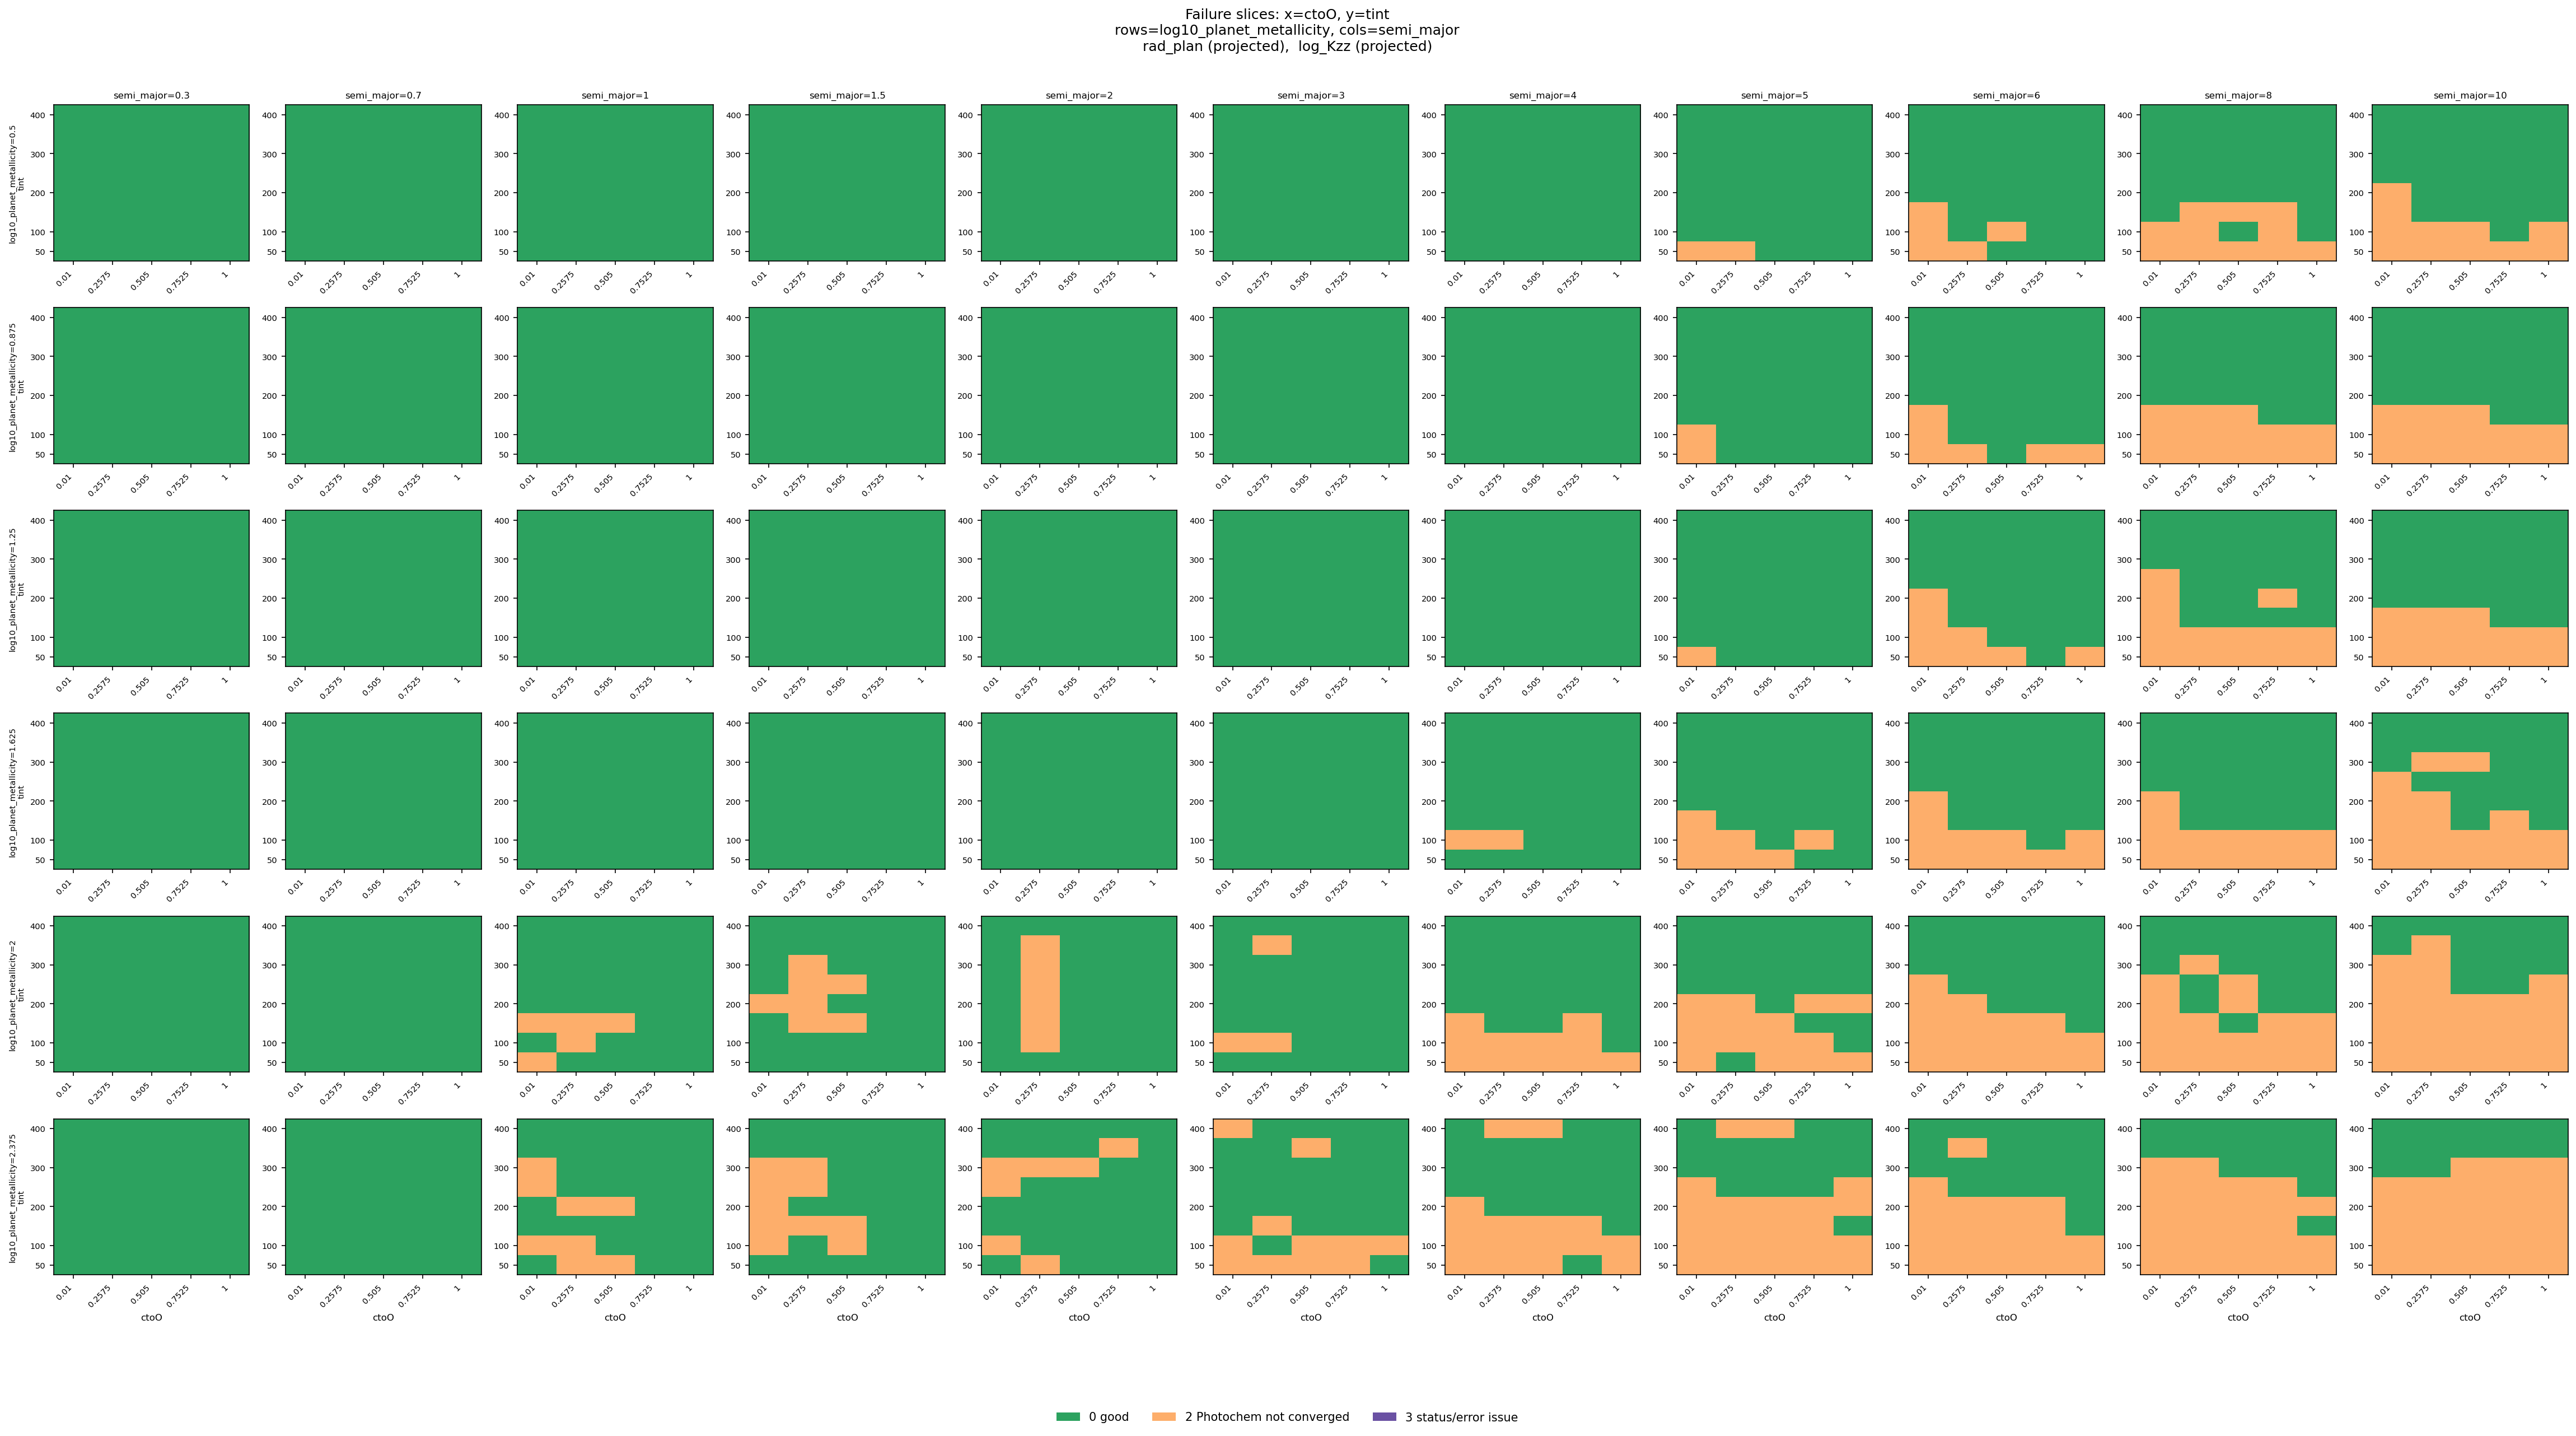

In [6]:
import sys
sys.path.insert(0, 'MiniNepGrid_Scripts')

from plot_failure_panel import plot_slice_panel
from IPython.display import Image, display

param_names = [
    "rad_plan",
    "log10_planet_metallicity",
    "tint",
    "semi_major",
    "ctoO",
    "log_Kzz",
]

out_path = "data/grid_results/failure_panel_lowmetal_restart.png"

plot_slice_panel(
    h5_path=dst_path,
    x_param=4,
    y_param=2,
    row_param=1,
    col_param=3,
    highlight_inputs_path=None,
    output_path=out_path,
    param_names=param_names,
    show_highlights=False,
    show_tp_fail=False,
    show_incomplete=False,
)

print(f"Saved: {out_path}")
display(Image(filename=out_path))

---
## Patch PICASO h5 — case [2.0, 0.875, 50.0, 8.0, 0.2575]

Overwrites the stored PICASO PT profile for this one case with the result from
`out_[2.0, 0.875, 50.0, 8.0, 0.2575].pkl` (a fresh re-run).

Run Cell A to inspect what will change, then Cell B to apply the write.
**Back up the h5 file before running Cell B if you haven't already.**

In [7]:
# Cell A — load pkl, locate grid index, compare current vs new (no writes yet)
import pickle

PICASO_H5 = 'data/grid_results/PICASO_climate_updatop_full_exploration_reducedrad_solveSegFault.h5'
PKL_PATH  = 'out_[2.0, 0.875, 50.0, 8.0, 0.2575].pkl'

# Grid values from get_gridvals_PICASO_TP() — full parameter exploration block
_rad   = np.array([2.0])
_metal = np.linspace(0.5, 3.5, 9)
_tint  = np.linspace(50, 400, 8)
_semi  = np.array([0.3, 0.7, 1.0, 1.5, 2.0, 3.0, 4.0, 5.0, 6.0, 8.0, 10.0])
_cto   = np.linspace(0.01, 1.0, 5)
picaso_grid_shape = (len(_rad), len(_metal), len(_tint), len(_semi), len(_cto))

CASE = [2.0, 0.875, 50.0, 8.0, 0.2575]
i_rad   = np.where(np.isclose(_rad,   CASE[0]))[0][0]
i_metal = np.where(np.isclose(_metal, CASE[1]))[0][0]
i_tint  = np.where(np.isclose(_tint,  CASE[2]))[0][0]
i_semi  = np.where(np.isclose(_semi,  CASE[3]))[0][0]
i_cto   = np.where(np.isclose(_cto,   CASE[4]))[0][0]
nd_idx  = (i_rad, i_metal, i_tint, i_semi, i_cto)
flat_idx = int(np.ravel_multi_index(nd_idx, picaso_grid_shape))

print(f'Case:        {CASE}')
print(f'Grid index:  {nd_idx}')
print(f'Flat index:  {flat_idx}  (of {np.prod(picaso_grid_shape)} total)')
print(f'Grid shape:  {picaso_grid_shape}')

# Load pkl
with open(PKL_PATH, 'rb') as f:
    pkl_out = pickle.load(f)

print(f'\npkl keys:    {list(pkl_out.keys())}')
pkl_P = np.atleast_1d(pkl_out['pressure'])
pkl_T = np.atleast_1d(pkl_out['temperature'])
pkl_conv = np.atleast_1d(pkl_out.get('converged', [0]))
print(f'pkl P range: {pkl_P.min():.3e} – {pkl_P.max():.3e} bar  ({len(pkl_P)} levels)')
print(f'pkl T range: {pkl_T.min():.1f} – {pkl_T.max():.1f} K')
print(f'pkl converged: {pkl_conv}')

# Show what is currently stored
with h5py.File(PICASO_H5, 'r') as f:
    cur_done = f['completed'][flat_idx]
    cur_P    = np.atleast_1d(f['results/pressure'][nd_idx])
    cur_T    = np.atleast_1d(f['results/temperature'][nd_idx])
    cur_conv = np.atleast_1d(f['results/converged'][nd_idx])

print(f'\nCurrent h5 entry (flat_idx={flat_idx}):')
print(f'  completed:  {cur_done}')
print(f'  converged:  {cur_conv}')
print(f'  P range:    {np.nanmin(cur_P):.3e} – {np.nanmax(cur_P):.3e} bar  ({len(cur_P)} levels)')
print(f'  T range:    {np.nanmin(cur_T):.1f} – {np.nanmax(cur_T):.1f} K')

Case:        [2.0, 0.875, 50.0, 8.0, 0.2575]
Grid index:  (0, 1, 0, 9, 1)
Flat index:  486  (of 3960 total)
Grid shape:  (1, 9, 8, 11, 5)

pkl keys:    ['pressure', 'temperature', 'converged', 'status', 'error']
pkl P range: 1.000e-06 – 1.000e+03 bar  (91 levels)
pkl T range: 64.6 – 1092.8 K
pkl converged: [[1]]

Current h5 entry (flat_idx=486):
  completed:  True
  converged:  [1]
  P range:    1.000e-06 – 1.000e+03 bar  (91 levels)
  T range:    10.0 – 825.9 K


In [8]:
# Cell B — apply the patch (WRITES to the PICASO h5)
# Run Cell A first to verify the index and inspect what will change.
# A backup of the original is saved before any write occurs.
import shutil

PICASO_H5_BACKUP = PICASO_H5.replace('.h5', '_backup.h5')
shutil.copy2(PICASO_H5, PICASO_H5_BACKUP)
print(f'Original backed up -> {PICASO_H5_BACKUP}')
print(f'Patching:             {PICASO_H5}')
print()

def _patch_dataset(ds, nd_idx, val):
    """Write val into ds[nd_idx], resizing or padding to match the existing slot length."""
    val_1d = np.atleast_1d(val)
    if ds.dtype.kind == 'S':
        # Fixed-length byte-string dataset: cast to the stored dtype
        ds[nd_idx] = val_1d.astype(ds.dtype)
    else:
        cur_len = len(np.atleast_1d(ds[nd_idx]))
        new_len = len(val_1d)
        if new_len > cur_len:
            new_shape = picaso_grid_shape + (new_len,)
            ds.resize(new_shape)
            ds[nd_idx] = val_1d
        elif new_len < cur_len:
            padded = np.pad(val_1d, (0, cur_len - new_len), constant_values=0)
            ds[nd_idx] = padded
        else:
            ds[nd_idx] = val_1d

# Build res dict matching PICASO_climate_model output format
def _to_bytes(v):
    v = np.atleast_1d(v)[0]
    return v.decode() if isinstance(v, (bytes, np.bytes_)) else str(v)

res = {
    'pressure':    np.atleast_1d(pkl_out['pressure']).astype(float),
    'temperature': np.atleast_1d(pkl_out['temperature']).astype(float),
    'converged':   np.atleast_1d(pkl_out.get('converged', np.array([0]))).astype(np.int64),
    'status':      np.array([_to_bytes(pkl_out.get('status', b'converged'))], dtype='S'),
    'error':       np.array([_to_bytes(pkl_out.get('error',  b''))],          dtype='S'),
}

with h5py.File(PICASO_H5, 'a') as f:
    for key, val in res.items():
        if key in f['results']:
            _patch_dataset(f['results'][key], nd_idx, val)
        else:
            print(f'WARNING: key "{key}" not found in h5 results — skipping')
    f['inputs'][flat_idx]    = np.array(CASE, dtype=float)
    f['completed'][flat_idx] = True

# Verify
with h5py.File(PICASO_H5, 'r') as f:
    new_done = f['completed'][flat_idx]
    new_P    = np.atleast_1d(f['results/pressure'][nd_idx])
    new_T    = np.atleast_1d(f['results/temperature'][nd_idx])
    new_conv = np.atleast_1d(f['results/converged'][nd_idx])

print('Patch applied. Verification:')
print(f'  completed:  {new_done}')
print(f'  converged:  {new_conv}')
print(f'  P range:    {np.nanmin(new_P):.3e} – {np.nanmax(new_P):.3e} bar  ({len(new_P)} levels)')
print(f'  T range:    {np.nanmin(new_T):.1f} – {np.nanmax(new_T):.1f} K')

Original backed up -> data/grid_results/PICASO_climate_updatop_full_exploration_reducedrad_solveSegFault_backup.h5
Patching:             data/grid_results/PICASO_climate_updatop_full_exploration_reducedrad_solveSegFault.h5

Patch applied. Verification:
  completed:  True
  converged:  [1]
  P range:    1.000e-06 – 1.000e+03 bar  (91 levels)
  T range:    64.6 – 1092.8 K


### Verification — PT profile match

Confirms the patched h5 entry now contains the same PT profile as
`out_[2.0, 0.875, 50.0, 8.0, 0.2575].pkl`.  
Three panels: pkl (ground truth) | patched h5 (should be identical) | old h5 from backup (for reference).
Numerical checks print the max absolute difference between pkl and the patched h5.

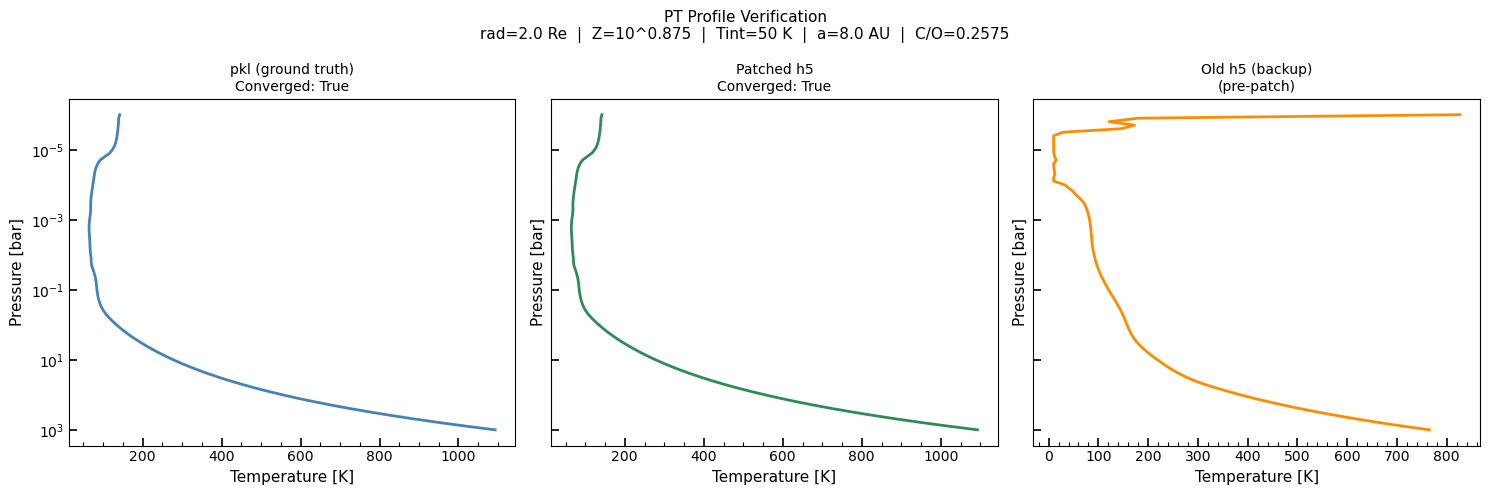

Numerical comparison — patched h5 vs pkl:
  max |ΔT| : 9.507112e+02 K   MISMATCH — check patch
  max |ΔP| : 1.000000e+03 bar MISMATCH — check patch
  h5 levels: 91   pkl levels: 91


In [9]:
import matplotlib.pyplot as plt

case_label = (f'rad={CASE[0]:.1f} Re  |  Z=10^{CASE[1]}  |  Tint={CASE[2]:.0f} K  |  '
              f'a={CASE[3]:.1f} AU  |  C/O={CASE[4]}')

# --- pkl (ground truth) ---
pkl_P = np.atleast_1d(pkl_out['pressure'])
pkl_T = np.atleast_1d(pkl_out['temperature'])
pkl_conv = bool(np.atleast_1d(pkl_out.get('converged', [0]))[0])

# --- patched h5 ---
with h5py.File(PICASO_H5, 'r') as f:
    h5_P    = np.atleast_1d(f['results/pressure'][nd_idx])
    h5_T    = np.atleast_1d(f['results/temperature'][nd_idx])
    h5_conv = bool(np.atleast_1d(f['results/converged'][nd_idx])[0])

# --- old h5 from backup (if it exists) ---
backup_exists = Path(PICASO_H5_BACKUP).exists()
if backup_exists:
    with h5py.File(PICASO_H5_BACKUP, 'r') as f:
        old_P = np.atleast_1d(f['results/pressure'][nd_idx])
        old_T = np.atleast_1d(f['results/temperature'][nd_idx])

# ── Plot ────────────────────────────────────────────────────────────────────
n_panels = 3 if backup_exists else 2
fig, axes = plt.subplots(1, n_panels, figsize=(5 * n_panels, 5), sharey=True)

def _pt_panel(ax, P, T, color, title):
    ax.semilogy(T, P, color=color, lw=2)
    ax.invert_yaxis()
    ax.set_xlabel('Temperature [K]', fontsize=11)
    ax.set_ylabel('Pressure [bar]', fontsize=11)
    ax.set_title(title, fontsize=10)
    ax.minorticks_on()
    ax.tick_params(which='major', length=6, width=1.2, direction='in')
    ax.tick_params(which='minor', length=3, width=0.8, direction='in')

_pt_panel(axes[0], pkl_P,  pkl_T,  'steelblue',  f'pkl (ground truth)\nConverged: {pkl_conv}')
_pt_panel(axes[1], h5_P,   h5_T,   'seagreen',   f'Patched h5\nConverged: {h5_conv}')
if backup_exists:
    _pt_panel(axes[2], old_P, old_T, 'darkorange', 'Old h5 (backup)\n(pre-patch)')

fig.suptitle(f'PT Profile Verification\n{case_label}', fontsize=11)
plt.tight_layout()
plt.show()

# ── Numerical checks ────────────────────────────────────────────────────────
# Interpolate h5 onto the pkl pressure grid for a fair comparison
# (arrays are identical after a successful patch, so differences should be ~0)
P_common = pkl_P[::-1]   # ascending for np.interp
h5_T_interp = np.interp(P_common, h5_P[::-1], h5_T[::-1])[::-1]
h5_P_interp = np.interp(P_common, h5_P[::-1], h5_P[::-1])[::-1]

max_dT = np.nanmax(np.abs(h5_T_interp - pkl_T))
max_dP = np.nanmax(np.abs(h5_P_interp - pkl_P))

print('Numerical comparison — patched h5 vs pkl:')
print(f'  max |ΔT| : {max_dT:.6e} K   {"PASS ✓" if max_dT < 1e-6 else "MISMATCH — check patch"}')
print(f'  max |ΔP| : {max_dP:.6e} bar {"PASS ✓" if max_dP < 1e-10 else "MISMATCH — check patch"}')
print(f'  h5 levels: {len(h5_P)}   pkl levels: {len(pkl_P)}')